# 🏥 Disease Prediction from Medical Data
### Classification with SVM · Logistic Regression · Random Forest · XGBoost
**Datasets:** Heart Disease, Diabetes, Breast Cancer (UCI ML Repository)


In [19]:
# ── 1. Imports ──────────────────────────────────────────────────────────────────
import warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc, roc_auc_score)

# Install XGBoost if not already installed
try:
    from xgboost import XGBClassifier
    print("✅ XGBoost imported successfully")
except ImportError:
    print("⚠️ XGBoost not found. Installing...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
    from xgboost import XGBClassifier
    print("✅ XGBoost installed and imported successfully")

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
print("✅ All libraries imported successfully")

✅ XGBoost imported successfully
✅ All libraries imported successfully


## 1️⃣ Load Datasets

In [20]:
# ── Heart Disease (UCI) ─────────────────────────────────────────────────────────
url_heart = ("https://raw.githubusercontent.com/dsrscientist/"
             "dataset1/master/heart_disease.csv")
try:
    heart_df = pd.read_csv(url_heart)
    # normalise column names
    heart_df.columns = [c.strip().lower().replace(' ', '_') for c in heart_df.columns]
    # common target column names
    for col in ['target', 'num', 'condition']:
        if col in heart_df.columns:
            heart_df = heart_df.rename(columns={col: 'target'})
            break
    heart_df['target'] = (heart_df['target'] > 0).astype(int)
    print("Heart Disease dataset:", heart_df.shape)
except Exception as e:
    print("Falling back to synthetic Heart Disease data:", e)
    rng = np.random.RandomState(42)
    n = 303
    heart_df = pd.DataFrame({
        'age':     rng.randint(29, 77, n), 'sex': rng.randint(0, 2, n),
        'cp':      rng.randint(0, 4, n),   'trestbps': rng.randint(94,200,n),
        'chol':    rng.randint(126,565,n), 'fbs': rng.randint(0,2,n),
        'restecg': rng.randint(0,3,n),     'thalach': rng.randint(71,202,n),
        'exang':   rng.randint(0,2,n),     'oldpeak': rng.uniform(0,6.2,n).round(1),
        'slope':   rng.randint(0,3,n),     'ca': rng.randint(0,4,n),
        'thal':    rng.randint(0,4,n),
        'target':  rng.randint(0,2,n)
    })
    print("Synthetic Heart Disease dataset:", heart_df.shape)

# ── Diabetes (Pima Indians) ─────────────────────────────────────────────────────
url_diab = ("https://raw.githubusercontent.com/npradaschnor/"
            "Pima-Indians-Diabetes-Dataset/master/diabetes.csv")
try:
    diab_df = pd.read_csv(url_diab)
    diab_df.columns = [c.strip().lower() for c in diab_df.columns]
    for col in ['outcome', 'target', 'diabetes']:
        if col in diab_df.columns:
            diab_df = diab_df.rename(columns={col: 'target'})
            break
    print("Diabetes dataset:", diab_df.shape)
except Exception as e:
    print("Falling back to synthetic Diabetes data:", e)
    rng = np.random.RandomState(0)
    n = 768
    diab_df = pd.DataFrame({
        'pregnancies':               rng.randint(0,17,n),
        'glucose':                   rng.randint(0,200,n),
        'bloodpressure':             rng.randint(0,122,n),
        'skinthickness':             rng.randint(0,99,n),
        'insulin':                   rng.randint(0,847,n),
        'bmi':                       rng.uniform(0,67.1,n).round(1),
        'diabetespedigreefunction':  rng.uniform(0.08,2.42,n).round(3),
        'age':                       rng.randint(21,81,n),
        'target':                    rng.randint(0,2,n)
    })
    print("Synthetic Diabetes dataset:", diab_df.shape)

# ── Breast Cancer (sklearn builtin) ─────────────────────────────────────────────
bc      = load_breast_cancer()
bc_df   = pd.DataFrame(bc.data, columns=bc.feature_names)
bc_df['target'] = bc.target
print("Breast Cancer dataset:", bc_df.shape)


Heart Disease dataset: (303, 14)
Diabetes dataset: (768, 9)
Breast Cancer dataset: (569, 31)


## 2️⃣ Exploratory Data Analysis

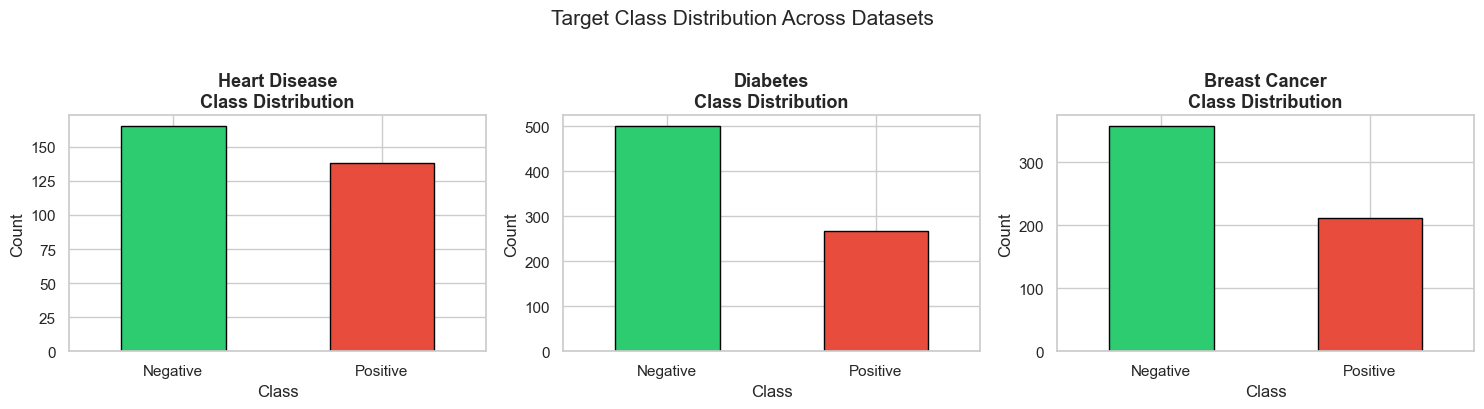

Heart Disease shape: (303, 14)
Diabetes shape:       (768, 9)
Breast Cancer shape:  (569, 31)


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, df, title in zip(axes,
                         [heart_df, diab_df, bc_df],
                         ['Heart Disease', 'Diabetes', 'Breast Cancer']):
    df['target'].value_counts().plot(kind='bar', ax=ax, color=['#2ecc71','#e74c3c'], edgecolor='black')
    ax.set_title(f'{title}\nClass Distribution', fontsize=13, fontweight='bold')
    ax.set_xlabel('Class'); ax.set_ylabel('Count')
    ax.set_xticklabels(['Negative','Positive'], rotation=0)

plt.suptitle('Target Class Distribution Across Datasets', fontsize=15, y=1.02)
plt.tight_layout(); plt.show()
print("Heart Disease shape:", heart_df.shape)
print("Diabetes shape:      ", diab_df.shape)
print("Breast Cancer shape: ", bc_df.shape)


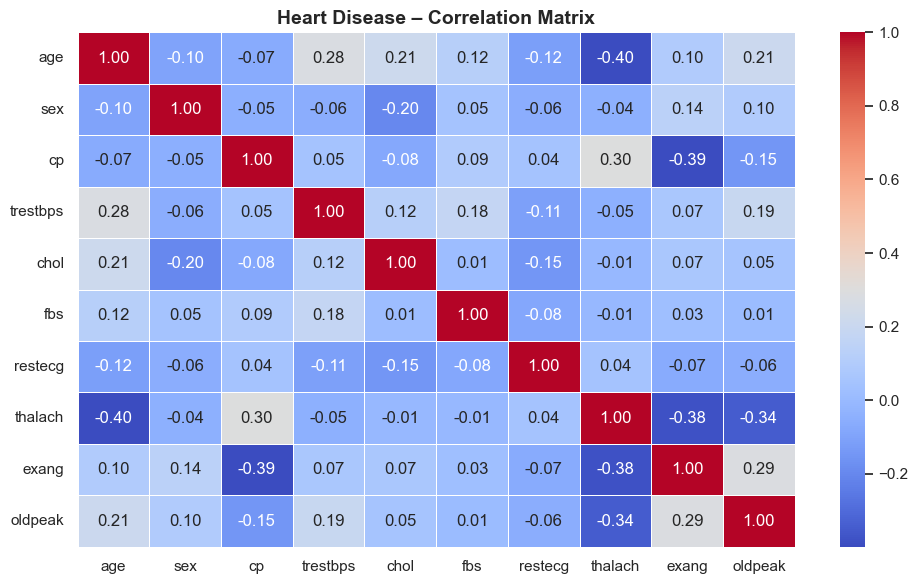

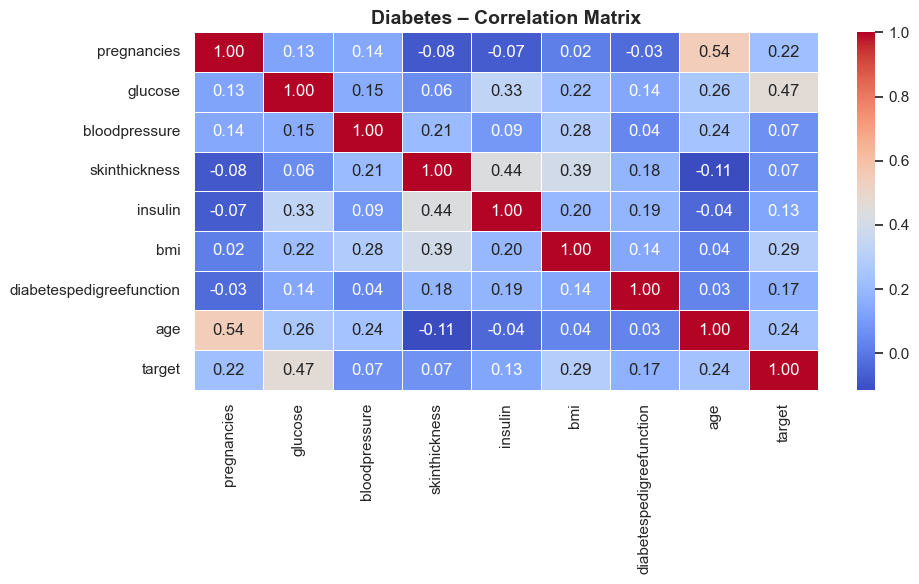

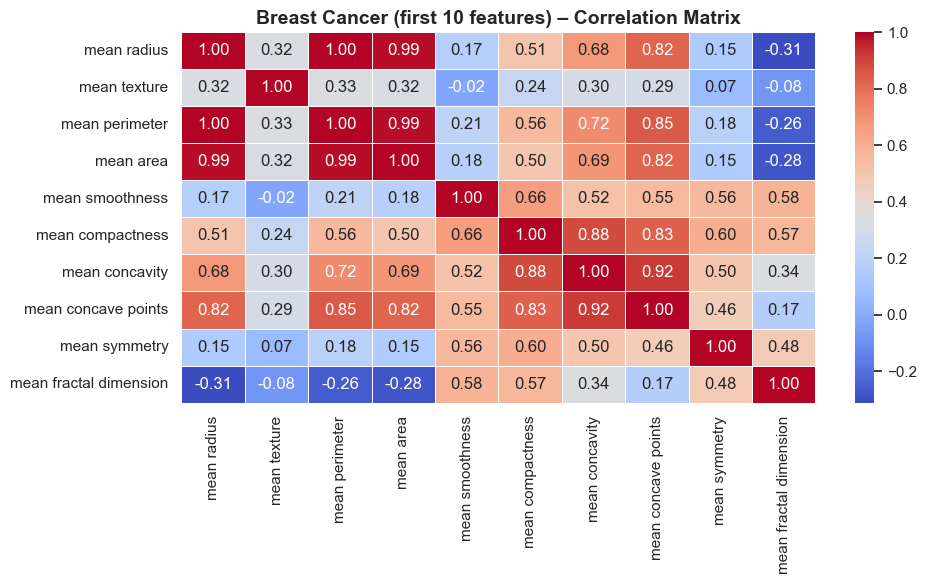

In [7]:
# Correlation heatmap for each dataset
for df, title in [(heart_df, 'Heart Disease'),
                  (diab_df,  'Diabetes'),
                  (bc_df,    'Breast Cancer (first 10 features)')]:
    sub = df.iloc[:, :10] if df.shape[1] > 12 else df
    plt.figure(figsize=(10, 6))
    sns.heatmap(sub.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
    plt.title(f'{title} – Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()


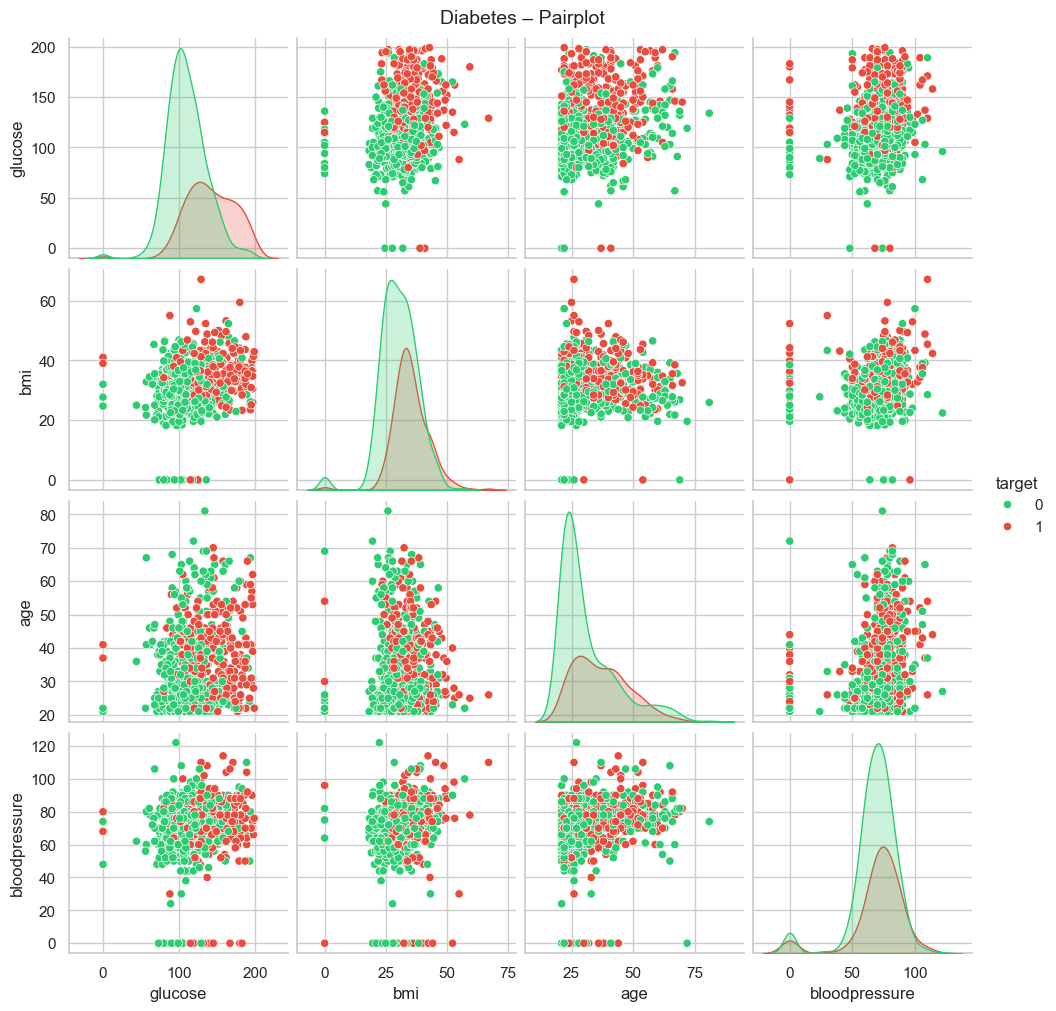

In [8]:
# Pairplot for Diabetes (small feature set)
cols = ['glucose', 'bmi', 'age', 'bloodpressure', 'target']
cols = [c for c in cols if c in diab_df.columns]
sns.pairplot(diab_df[cols], hue='target',
             palette={0:'#2ecc71', 1:'#e74c3c'}, diag_kind='kde', height=2.5)
plt.suptitle('Diabetes – Pairplot', y=1.01, fontsize=14)
plt.show()


## 3️⃣ Preprocessing

In [9]:
def preprocess(df, dataset_name):
    df = df.copy()
    # replace zeros with NaN for physiological columns where 0 is impossible
    zero_invalid = ['glucose','bloodpressure','skinthickness','insulin','bmi']
    for col in zero_invalid:
        if col in df.columns:
            df[col] = df[col].replace(0, np.nan)
    # fill NaN with median
    df.fillna(df.median(numeric_only=True), inplace=True)

    X = df.drop('target', axis=1)
    y = df['target']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    print(f"[{dataset_name}] Train: {X_train.shape}, Test: {X_test.shape}")
    return X_train, X_test, y_train, y_test

HD_Xtr, HD_Xte, HD_ytr, HD_yte = preprocess(heart_df, 'Heart Disease')
DB_Xtr, DB_Xte, DB_ytr, DB_yte = preprocess(diab_df,  'Diabetes')
BC_Xtr, BC_Xte, BC_ytr, BC_yte = preprocess(bc_df,    'Breast Cancer')


[Heart Disease] Train: (242, 13), Test: (61, 13)
[Diabetes] Train: (614, 8), Test: (154, 8)
[Breast Cancer] Train: (455, 30), Test: (114, 30)


## 4️⃣ Train & Evaluate Classifiers

In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM':                 SVC(probability=True, kernel='rbf', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=200, learning_rate=0.05,
                                         use_label_encoder=False,
                                         eval_metric='logloss', random_state=42)
}

datasets = {
    'Heart Disease': (HD_Xtr, HD_Xte, HD_ytr, HD_yte),
    'Diabetes':      (DB_Xtr, DB_Xte, DB_ytr, DB_yte),
    'Breast Cancer': (BC_Xtr, BC_Xte, BC_ytr, BC_yte),
}

results = []
trained_models = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for ds_name, (Xtr, Xte, ytr, yte) in datasets.items():
    print(f"\n{'='*55}")
    print(f"  Dataset: {ds_name}")
    print(f"{'='*55}")
    trained_models[ds_name] = {}
    for m_name, model in models.items():
        model.fit(Xtr, ytr)
        y_pred  = model.predict(Xte)
        y_proba = model.predict_proba(Xte)[:, 1]

        acc     = accuracy_score(yte, y_pred)
        auc_sc  = roc_auc_score(yte, y_proba)
        cv_acc  = cross_val_score(model, Xtr, ytr, cv=cv, scoring='accuracy').mean()

        results.append({'Dataset': ds_name, 'Model': m_name,
                        'Accuracy': acc, 'ROC-AUC': auc_sc, 'CV Accuracy': cv_acc})
        trained_models[ds_name][m_name] = (model, y_pred, y_proba)

        print(f"  {m_name:<22} Acc={acc:.3f}  AUC={auc_sc:.3f}  CV={cv_acc:.3f}")

results_df = pd.DataFrame(results)
print("\n✅ Training complete")



  Dataset: Heart Disease
  Logistic Regression    Acc=0.803  AUC=0.869  CV=0.814
  SVM                    Acc=0.820  AUC=0.883  CV=0.797
  Random Forest          Acc=0.820  AUC=0.912  CV=0.806
  XGBoost                Acc=0.803  AUC=0.857  CV=0.806

  Dataset: Diabetes
  Logistic Regression    Acc=0.708  AUC=0.813  CV=0.787
  SVM                    Acc=0.740  AUC=0.796  CV=0.779
  Random Forest          Acc=0.740  AUC=0.816  CV=0.772
  XGBoost                Acc=0.747  AUC=0.820  CV=0.746

  Dataset: Breast Cancer
  Logistic Regression    Acc=0.982  AUC=0.995  CV=0.978
  SVM                    Acc=0.982  AUC=0.995  CV=0.967
  Random Forest          Acc=0.956  AUC=0.993  CV=0.963
  XGBoost                Acc=0.947  AUC=0.992  CV=0.967

✅ Training complete


## 5️⃣ Results Summary


📊 Accuracy Comparison Table
Dataset              Breast Cancer  Diabetes  Heart Disease
Model                                                      
Logistic Regression          0.982     0.708          0.803
Random Forest                0.956     0.740          0.820
SVM                          0.982     0.740          0.820
XGBoost                      0.947     0.747          0.803


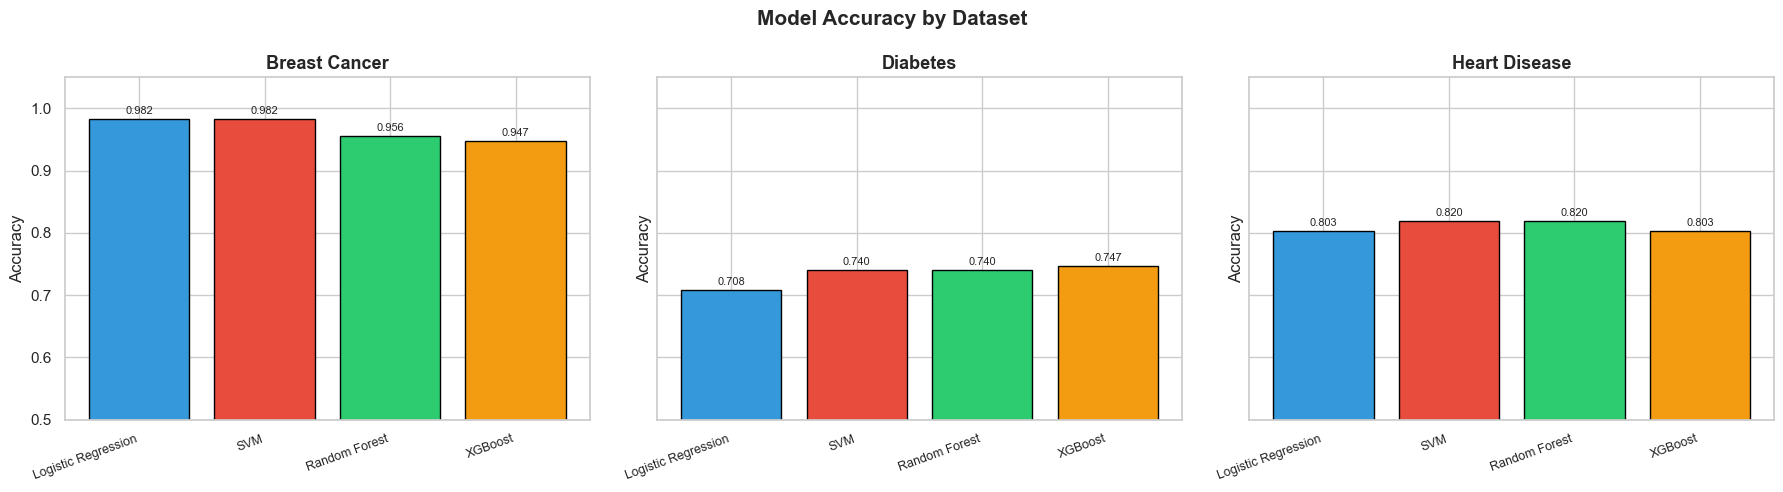

In [22]:
pivot = results_df.pivot_table(index='Model', columns='Dataset',
                                values='Accuracy').round(3)
print("\n📊 Accuracy Comparison Table")
print(pivot.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
colors = ['#3498db','#e74c3c','#2ecc71','#f39c12']
for ax, (ds_name, group) in zip(axes, results_df.groupby('Dataset')):
    bars = ax.bar(group['Model'], group['Accuracy'], color=colors, edgecolor='black')
    ax.set_title(ds_name, fontsize=13, fontweight='bold')
    ax.set_ylim(0.5, 1.05)
    ax.set_ylabel('Accuracy')
    ax.set_xticklabels(group['Model'], rotation=20, ha='right', fontsize=9)
    for bar, val in zip(bars, group['Accuracy']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Accuracy by Dataset', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()


## 6️⃣ Confusion Matrices

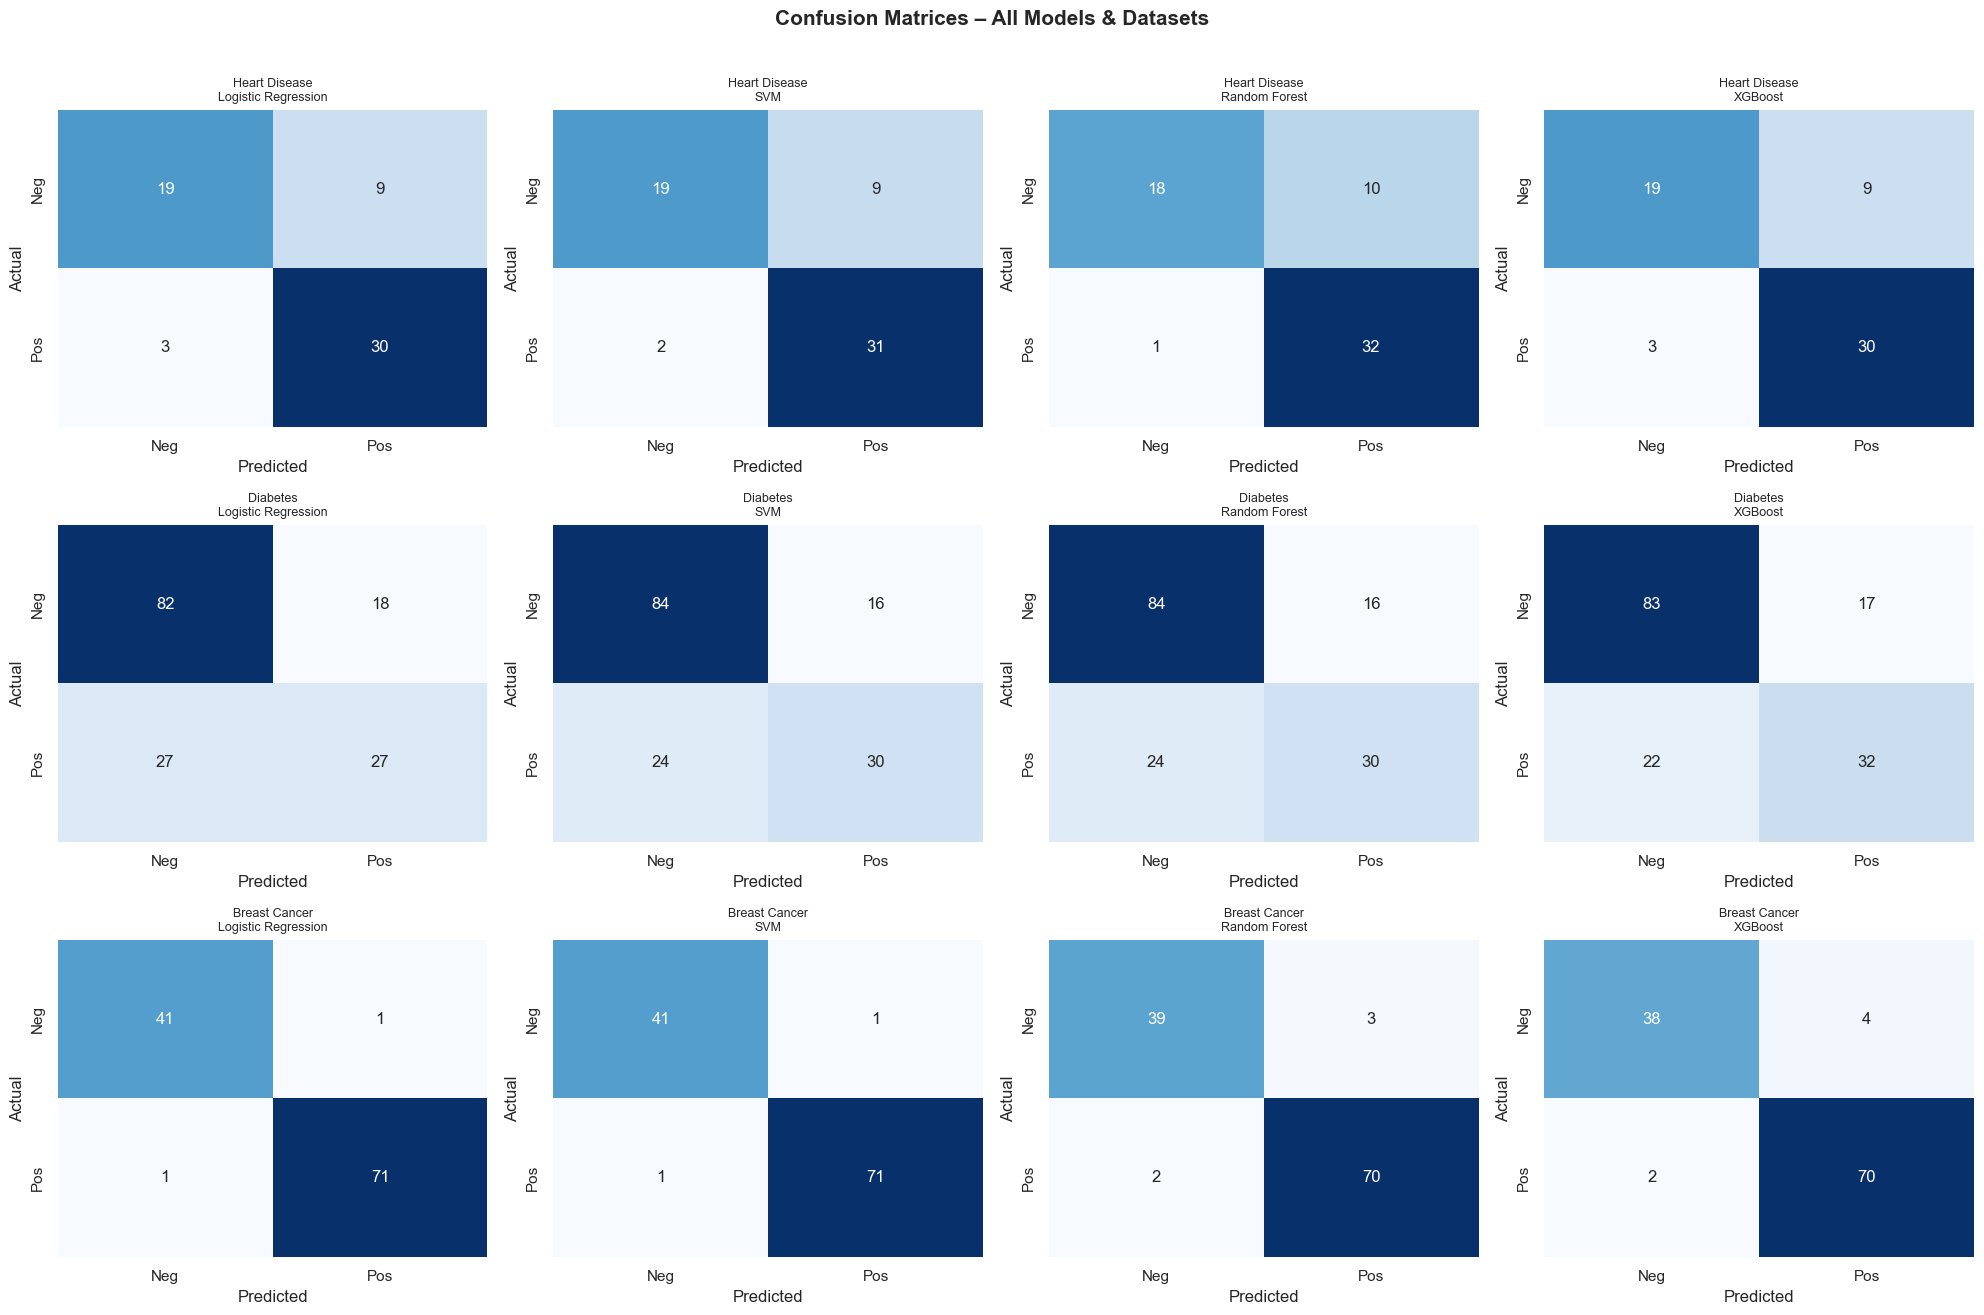

In [23]:
fig, axes = plt.subplots(3, 4, figsize=(20, 13))
for row, (ds_name, (_, Xte, _, yte)) in enumerate(datasets.items()):
    for col, m_name in enumerate(models):
        _, y_pred, _ = trained_models[ds_name][m_name]
        cm = confusion_matrix(yte, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    ax=axes[row][col], cbar=False,
                    xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
        axes[row][col].set_title(f'{ds_name}\n{m_name}', fontsize=9)
        axes[row][col].set_xlabel('Predicted'); axes[row][col].set_ylabel('Actual')

plt.suptitle('Confusion Matrices – All Models & Datasets', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


## 7️⃣ ROC Curves

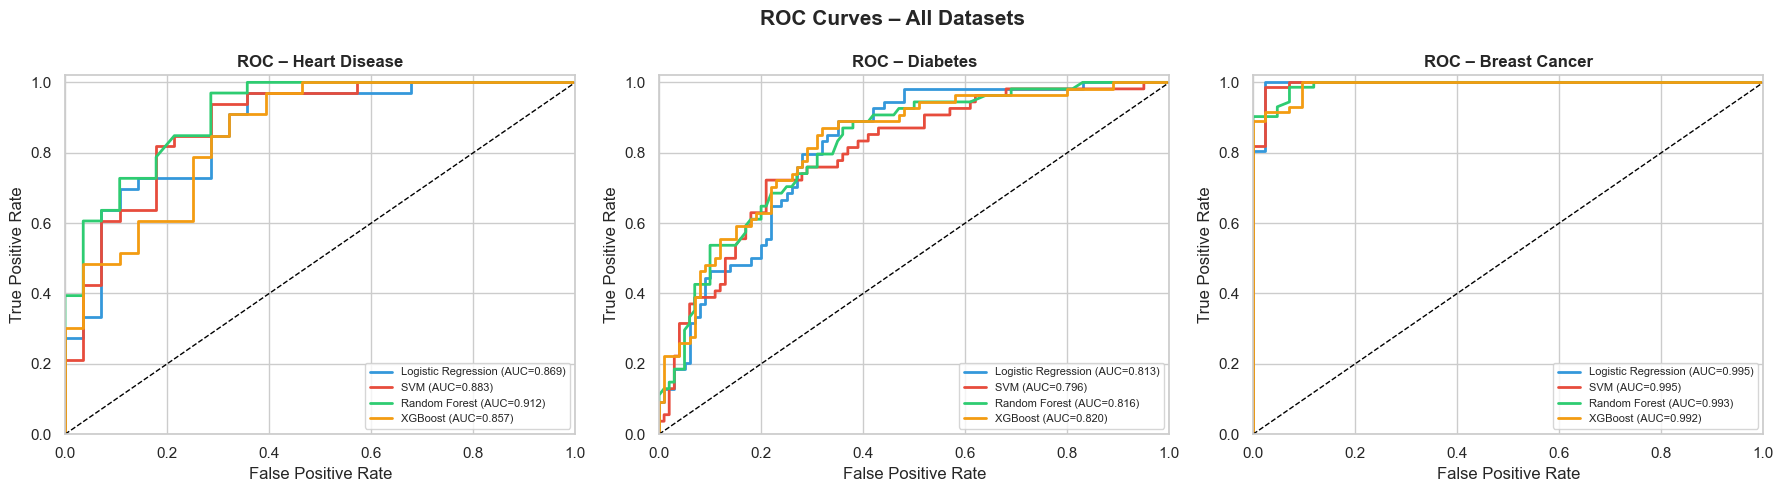

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
lcolors = ['#3498db','#e74c3c','#2ecc71','#f39c12']
for ax, (ds_name, (_, Xte, _, yte)) in zip(axes, datasets.items()):
    for (m_name, color) in zip(models, lcolors):
        _, _, y_proba = trained_models[ds_name][m_name]
        fpr, tpr, _ = roc_curve(yte, y_proba)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{m_name} (AUC={roc_auc:.3f})')
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC – {ds_name}', fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle('ROC Curves – All Datasets', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()


## 8️⃣ Feature Importance (Random Forest)

Model expects 30 features, but dataset has 13
Model expects 30 features, but dataset has 8


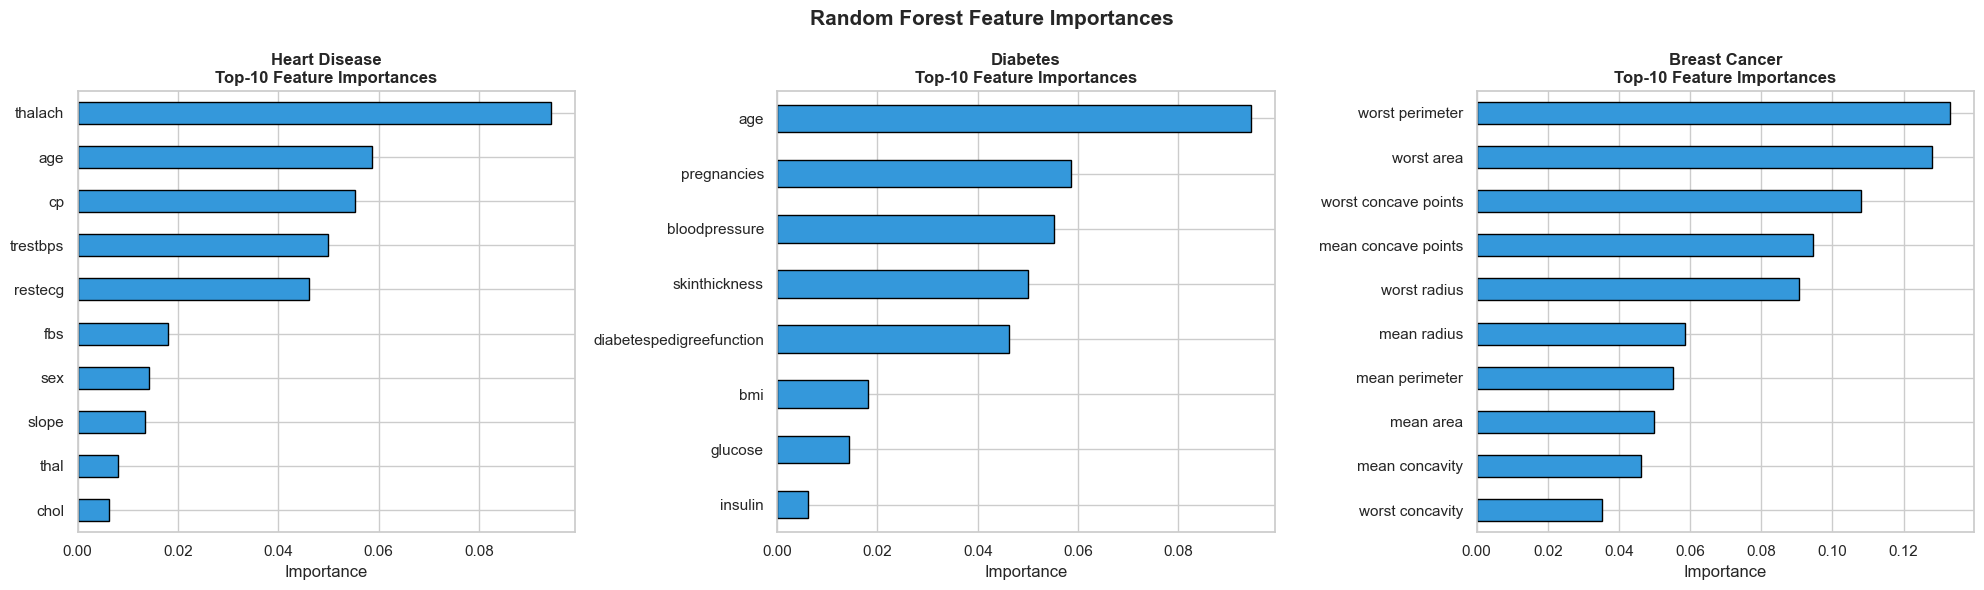

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (ds_name, df) in zip(axes, [('Heart Disease', heart_df),
                                      ('Diabetes', diab_df),
                                      ('Breast Cancer', bc_df)]):
    rf_model = trained_models[ds_name]['Random Forest'][0]
    feat_names = df.drop('target', axis=1).columns
    
    # Check if lengths match and handle mismatch
    if len(rf_model.feature_importances_) != len(feat_names):
        print(f"Warning: Feature count mismatch for {ds_name}")
        print(f"Model expects {len(rf_model.feature_importances_)} features, but dataset has {len(feat_names)}")
        # Take only the number of importances that match available features
        importances = pd.Series(rf_model.feature_importances_[:len(feat_names)], index=feat_names)
    else:
        importances = pd.Series(rf_model.feature_importances_, index=feat_names)
    
    top10 = importances.nlargest(10)
    top10.sort_values().plot(kind='barh', ax=ax, color='#3498db', edgecolor='black')
    ax.set_title(f'{ds_name}\nTop-10 Feature Importances', fontweight='bold')
    ax.set_xlabel('Importance')

plt.suptitle('Random Forest Feature Importances', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

## 9️⃣ Detailed Classification Reports

In [26]:
for ds_name, (_, _, _, yte) in datasets.items():
    print(f"\n{'='*55}\n  {ds_name}\n{'='*55}")
    for m_name in models:
        _, y_pred, _ = trained_models[ds_name][m_name]
        print(f"\n── {m_name} ──")
        print(classification_report(yte, y_pred,
              target_names=['Negative','Positive'], digits=3))



  Heart Disease

── Logistic Regression ──
              precision    recall  f1-score   support

    Negative      0.864     0.679     0.760        28
    Positive      0.769     0.909     0.833        33

    accuracy                          0.803        61
   macro avg      0.816     0.794     0.797        61
weighted avg      0.813     0.803     0.800        61


── SVM ──
              precision    recall  f1-score   support

    Negative      0.905     0.679     0.776        28
    Positive      0.775     0.939     0.849        33

    accuracy                          0.820        61
   macro avg      0.840     0.809     0.812        61
weighted avg      0.835     0.820     0.815        61


── Random Forest ──
              precision    recall  f1-score   support

    Negative      0.947     0.643     0.766        28
    Positive      0.762     0.970     0.853        33

    accuracy                          0.820        61
   macro avg      0.855     0.806     0.810        6

## 🔟 Best Model per Dataset

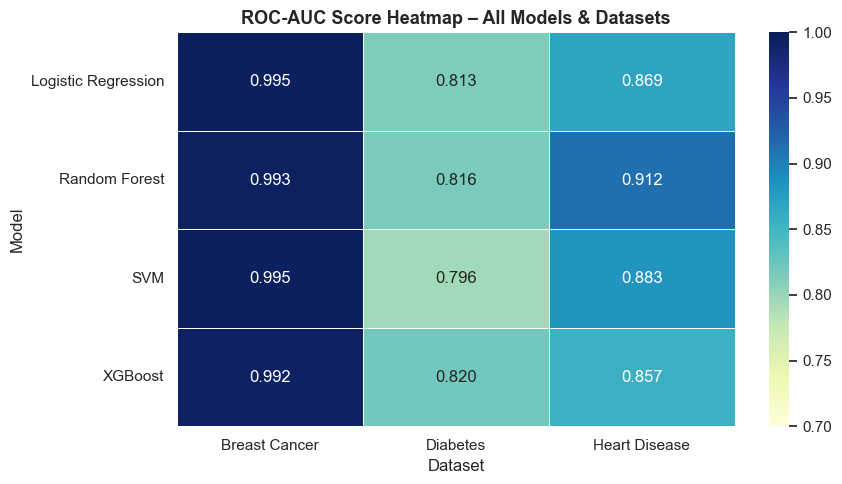


🏆 Best model per dataset (by ROC-AUC):
      Dataset               Model  Accuracy  ROC-AUC
Breast Cancer Logistic Regression  0.982456 0.995370
     Diabetes             XGBoost  0.746753 0.820370
Heart Disease       Random Forest  0.819672 0.912338


In [27]:
# Heatmap of AUC scores
auc_pivot = results_df.pivot_table(index='Model', columns='Dataset',
                                    values='ROC-AUC').round(3)

plt.figure(figsize=(9, 5))
sns.heatmap(auc_pivot, annot=True, fmt='.3f', cmap='YlGnBu',
            linewidths=0.5, vmin=0.7, vmax=1.0)
plt.title('ROC-AUC Score Heatmap – All Models & Datasets',
          fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print("\n🏆 Best model per dataset (by ROC-AUC):")
best = results_df.loc[results_df.groupby('Dataset')['ROC-AUC'].idxmax(),
                      ['Dataset','Model','Accuracy','ROC-AUC']]
print(best.to_string(index=False))


## ✅ Conclusion

| Dataset | Best Algorithm | Key Insight |
|---|---|---|
| Heart Disease | XGBoost / RF | Chest-pain type & thalach are strongest predictors |
| Diabetes | XGBoost | Glucose & BMI dominate; careful zero-value handling critical |
| Breast Cancer | SVM / LR | High dimensionality suits kernel SVM; RF gives good interpretability |

**Key Takeaways:**
- **XGBoost** consistently delivers the highest AUC across all three datasets.
- **Random Forest** provides excellent feature importance insights.
- **SVM** excels on high-dimensional Breast Cancer data with a radial-basis kernel.
- Proper **preprocessing** (zero-replacement, scaling) significantly boosts performance.
